In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
patients = pd.read_csv(
    r"F:\healthcare_patient_operations_analytics\data\patients.csv"
)

departments = pd.read_csv(
    r"F:\healthcare_patient_operations_analytics\data\departments.csv"
)

providers = pd.read_csv(
    r"F:\healthcare_patient_operations_analytics\data\providers.csv"
)

appointments = pd.read_csv(
    r"F:\healthcare_patient_operations_analytics\data\appointments.csv"
)

visits = pd.read_csv(
    r"F:\healthcare_patient_operations_analytics\data\visits.csv"
)

billing = pd.read_csv(
    r"F:\healthcare_patient_operations_analytics\data\billing.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [4]:
print("Patients:", patients.shape)
print("Departments:", departments.shape)
print("Providers:", providers.shape)
print("Appointments:", appointments.shape)
print("Visits:", visits.shape)
print("Billing:", billing.shape)

Patients: (6000, 8)
Departments: (10, 4)
Providers: (80, 5)
Appointments: (150000, 10)
Visits: (121977, 11)
Billing: (121977, 11)


In [5]:
print("\nPatients columns:")
print(patients.columns.tolist())

print("\nAppointments columns:")
print(appointments.columns.tolist())

print("\nVisits columns:")
print(visits.columns.tolist())

print("\nBilling columns:")
print(billing.columns.tolist())


Patients columns:
['patient_id', 'patient_name', 'age', 'gender', 'city', 'insurance_type', 'registration_date', 'age_group']

Appointments columns:
['appointment_id', 'patient_id', 'provider_id', 'department_id', 'appointment_date', 'appointment_time', 'appointment_status', 'appointment_type', 'booking_channel', 'scheduled_days_ahead']

Visits columns:
['visit_id', 'appointment_id', 'patient_id', 'provider_id', 'department_id', 'visit_date', 'check_in_time', 'consultation_start_time', 'consultation_end_time', 'visit_type', 'diagnosis_category']

Billing columns:
['bill_id', 'visit_id', 'patient_id', 'department_id', 'bill_date', 'consultation_fee', 'procedure_amount', 'medication_amount', 'total_amount', 'payment_method', 'payment_status']


In [6]:
print("PATIENTS")
print(patients.shape)
print(patients.head())

print("\nDEPARTMENTS")
print(departments.shape)
print(departments.head())

print("\nPROVIDERS")
print(providers.shape)
print(providers.head())

print("\nAPPOINTMENTS")
print(appointments.shape)
print(appointments.head())

print("\nVISITS")
print(visits.shape)
print(visits.head())

print("\nBILLING")
print(billing.shape)
print(billing.head())

PATIENTS
(6000, 8)
  patient_id   patient_name  age  gender       city insurance_type  \
0     P00001  Patient_00001   47    Male  Bengaluru      Corporate   
1     P00002  Patient_00002   82    Male     Mumbai      Corporate   
2     P00003  Patient_00003   64  Female      Delhi      Corporate   
3     P00004  Patient_00004   58  Female  Ahmedabad        Private   
4     P00005  Patient_00005   36    Male     Jaipur       Self-Pay   

  registration_date age_group  
0        2025-09-20     40-49  
1        2025-01-26       70+  
2        2025-01-29     60-69  
3        2025-09-16     50-59  
4        2025-04-15     30-39  

DEPARTMENTS
(10, 4)
  department_id department_name   location    specialty
0          D001      Cardiology  Bengaluru   Cardiology
1          D002     Orthopedics     Mumbai  Orthopedics
2          D003     Dermatology      Delhi  Dermatology
3          D004      Pediatrics  Hyderabad   Pediatrics
4          D005       Neurology    Chennai    Neurology

PROVIDERS


In [7]:
print("Missing values by dataset:\n")

print("Patients:", patients.isnull().sum().sum())
print("Departments:", departments.isnull().sum().sum())
print("Providers:", providers.isnull().sum().sum())
print("Appointments:", appointments.isnull().sum().sum())
print("Visits:", visits.isnull().sum().sum())
print("Billing:", billing.isnull().sum().sum())

Missing values by dataset:

Patients: 0
Departments: 0
Providers: 0
Appointments: 0
Visits: 0
Billing: 0


In [8]:
print("ROW COUNTS")
print("--------------------")
print("Patients:", len(patients))
print("Departments:", len(departments))
print("Providers:", len(providers))
print("Appointments:", len(appointments))
print("Visits:", len(visits))
print("Billing:", len(billing))

print("\nMISSING VALUES")
print("--------------------")
print("Patients:", patients.isnull().sum().sum())
print("Departments:", departments.isnull().sum().sum())
print("Providers:", providers.isnull().sum().sum())
print("Appointments:", appointments.isnull().sum().sum())
print("Visits:", visits.isnull().sum().sum())
print("Billing:", billing.isnull().sum().sum())

ROW COUNTS
--------------------
Patients: 6000
Departments: 10
Providers: 80
Appointments: 150000
Visits: 121977
Billing: 121977

MISSING VALUES
--------------------
Patients: 0
Departments: 0
Providers: 0
Appointments: 0
Visits: 0
Billing: 0


In [9]:
# Convert date columns to datetime

patients["registration_date"] = pd.to_datetime(
    patients["registration_date"]
)

appointments["appointment_date"] = pd.to_datetime(
    appointments["appointment_date"]
)

visits["visit_date"] = pd.to_datetime(
    visits["visit_date"]
)

visits["check_in_time"] = pd.to_datetime(
    visits["check_in_time"]
)

visits["consultation_start_time"] = pd.to_datetime(
    visits["consultation_start_time"]
)

visits["consultation_end_time"] = pd.to_datetime(
    visits["consultation_end_time"]
)

billing["bill_date"] = pd.to_datetime(
    billing["bill_date"]
)

print("Date and time columns converted successfully.")

Date and time columns converted successfully.


In [10]:
print("Patients registration_date:")
print(patients["registration_date"].dtype)

print("\nAppointments appointment_date:")
print(appointments["appointment_date"].dtype)

print("\nVisits date/time columns:")
print(
    visits[
        [
            "visit_date",
            "check_in_time",
            "consultation_start_time",
            "consultation_end_time"
        ]
    ].dtypes
)

print("\nBilling bill_date:")
print(billing["bill_date"].dtype)

Patients registration_date:
datetime64[ns]

Appointments appointment_date:
datetime64[ns]

Visits date/time columns:
visit_date                 datetime64[ns]
check_in_time              datetime64[ns]
consultation_start_time    datetime64[ns]
consultation_end_time      datetime64[ns]
dtype: object

Billing bill_date:
datetime64[ns]


In [11]:
visits["wait_time_minutes"] = (
    visits["consultation_start_time"]
    - visits["check_in_time"]
).dt.total_seconds() / 60

visits["wait_time_minutes"] = (
    visits["wait_time_minutes"].round(2)
)

print(visits[
    [
        "visit_id",
        "check_in_time",
        "consultation_start_time",
        "wait_time_minutes"
    ]
].head(10))

  visit_id       check_in_time consultation_start_time  wait_time_minutes
0  V000001 2025-12-10 14:03:00     2025-12-10 14:35:00               32.0
1  V000002 2025-01-25 17:36:00     2025-01-25 17:41:00                5.0
2  V000003 2025-09-06 13:37:00     2025-09-06 14:02:00               25.0
3  V000004 2025-07-09 14:43:00     2025-07-09 15:16:00               33.0
4  V000005 2025-03-11 09:06:00     2025-03-11 09:33:00               27.0
5  V000006 2025-06-29 14:40:00     2025-06-29 14:45:00                5.0
6  V000007 2025-08-17 14:59:00     2025-08-17 15:37:00               38.0
7  V000008 2025-10-16 08:37:00     2025-10-16 09:13:00               36.0
8  V000009 2025-07-18 08:11:00     2025-07-18 08:41:00               30.0
9  V000010 2025-11-30 16:32:00     2025-11-30 17:20:00               48.0


In [12]:
visits["consultation_duration_minutes"] = (
    visits["consultation_end_time"]
    - visits["consultation_start_time"]
).dt.total_seconds() / 60

visits["consultation_duration_minutes"] = (
    visits["consultation_duration_minutes"].round(2)
)

print(visits[
    [
        "visit_id",
        "consultation_start_time",
        "consultation_end_time",
        "consultation_duration_minutes"
    ]
].head(10))

  visit_id consultation_start_time consultation_end_time  \
0  V000001     2025-12-10 14:35:00   2025-12-10 14:55:00   
1  V000002     2025-01-25 17:41:00   2025-01-25 17:58:00   
2  V000003     2025-09-06 14:02:00   2025-09-06 14:20:00   
3  V000004     2025-07-09 15:16:00   2025-07-09 15:54:00   
4  V000005     2025-03-11 09:33:00   2025-03-11 09:52:00   
5  V000006     2025-06-29 14:45:00   2025-06-29 15:05:00   
6  V000007     2025-08-17 15:37:00   2025-08-17 16:06:00   
7  V000008     2025-10-16 09:13:00   2025-10-16 09:41:00   
8  V000009     2025-07-18 08:41:00   2025-07-18 09:15:00   
9  V000010     2025-11-30 17:20:00   2025-11-30 17:35:00   

   consultation_duration_minutes  
0                           20.0  
1                           17.0  
2                           18.0  
3                           38.0  
4                           19.0  
5                           20.0  
6                           29.0  
7                           28.0  
8                       

In [13]:
print("Wait time summary:")
print(visits["wait_time_minutes"].describe())

print("\nConsultation duration summary:")
print(visits["consultation_duration_minutes"].describe())

Wait time summary:
count    121977.000000
mean         32.754732
std          13.481146
min           5.000000
25%          23.000000
50%          33.000000
75%          42.000000
max          90.000000
Name: wait_time_minutes, dtype: float64

Consultation duration summary:
count    121977.000000
mean         24.541397
std           9.911220
min           8.000000
25%          17.000000
50%          24.000000
75%          31.000000
max          69.000000
Name: consultation_duration_minutes, dtype: float64


In [14]:
department_wait_time = (
    visits
    .merge(
        departments[
            ["department_id", "department_name", "location"]
        ],
        on="department_id",
        how="left"
    )
    .groupby(
        ["department_id", "department_name", "location"]
    )
    .agg({
        "visit_id": "count",
        "wait_time_minutes": "mean"
    })
    .reset_index()
)

department_wait_time.columns = [
    "department_id",
    "department_name",
    "location",
    "completed_visits",
    "average_wait_minutes"
]

department_wait_time["average_wait_minutes"] = (
    department_wait_time["average_wait_minutes"]
    .round(2)
)

department_wait_time = department_wait_time.sort_values(
    "average_wait_minutes",
    ascending=False
)

department_wait_time

,department_id,department_name,location,completed_visits,average_wait_minutes
9,D010,General Surgery,Bhubaneswar,13310,44.38
4,D005,Neurology,Chennai,6248,41.46
3,D004,Pediatrics,Hyderabad,19209,38.53
6,D007,Gynecology,Kolkata,7743,35.61
1,D002,Orthopedics,Mumbai,12444,33.43
5,D006,General Medicine,Pune,13248,30.42
0,D001,Cardiology,Bengaluru,26847,27.59
7,D008,ENT,Ahmedabad,10499,26.85
2,D003,Dermatology,Delhi,7680,23.86
8,D009,Ophthalmology,Jaipur,4749,22.12


In [15]:
department_consultation_time = (
    visits
    .merge(
        departments[
            ["department_id", "department_name", "location"]
        ],
        on="department_id",
        how="left"
    )
    .groupby(
        ["department_id", "department_name", "location"]
    )
    .agg({
        "visit_id": "count",
        "consultation_duration_minutes": "mean"
    })
    .reset_index()
)

department_consultation_time.columns = [
    "department_id",
    "department_name",
    "location",
    "completed_visits",
    "average_consultation_minutes"
]

department_consultation_time["average_consultation_minutes"] = (
    department_consultation_time["average_consultation_minutes"]
    .round(2)
)

department_consultation_time = department_consultation_time.sort_values(
    "average_consultation_minutes",
    ascending=False
)

department_consultation_time

,department_id,department_name,location,completed_visits,average_consultation_minutes
9,D010,General Surgery,Bhubaneswar,13310,39.53
4,D005,Neurology,Chennai,6248,31.57
1,D002,Orthopedics,Mumbai,12444,27.61
6,D007,Gynecology,Kolkata,7743,24.62
0,D001,Cardiology,Bengaluru,26847,23.58
3,D004,Pediatrics,Hyderabad,19209,21.68
8,D009,Ophthalmology,Jaipur,4749,20.65
2,D003,Dermatology,Delhi,7680,19.86
7,D008,ENT,Ahmedabad,10499,18.92
5,D006,General Medicine,Pune,13248,17.91


In [16]:
department_operational_analysis = pd.merge(
    department_wait_time,
    department_consultation_time[
        [
            "department_id",
            "average_consultation_minutes"
        ]
    ],
    on="department_id",
    how="left"
)

department_operational_analysis

,department_id,department_name,location,completed_visits,average_wait_minutes,average_consultation_minutes
0,D010,General Surgery,Bhubaneswar,13310,44.38,39.53
1,D005,Neurology,Chennai,6248,41.46,31.57
2,D004,Pediatrics,Hyderabad,19209,38.53,21.68
3,D007,Gynecology,Kolkata,7743,35.61,24.62
4,D002,Orthopedics,Mumbai,12444,33.43,27.61
5,D006,General Medicine,Pune,13248,30.42,17.91
6,D001,Cardiology,Bengaluru,26847,27.59,23.58
7,D008,ENT,Ahmedabad,10499,26.85,18.92
8,D003,Dermatology,Delhi,7680,23.86,19.86
9,D009,Ophthalmology,Jaipur,4749,22.12,20.65


In [17]:
department_operational_analysis = pd.merge(
    department_wait_time[
        [
            "department_id",
            "department_name",
            "location",
            "completed_visits",
            "average_wait_minutes"
        ]
    ],
    department_consultation_time[
        [
            "department_id",
            "average_consultation_minutes"
        ]
    ],
    on="department_id",
    how="left"
)

department_operational_analysis = (
    department_operational_analysis
    .sort_values(
        "average_wait_minutes",
        ascending=False
    )
    .reset_index(drop=True)
)

department_operational_analysis

,department_id,department_name,location,completed_visits,average_wait_minutes,average_consultation_minutes
0,D010,General Surgery,Bhubaneswar,13310,44.38,39.53
1,D005,Neurology,Chennai,6248,41.46,31.57
2,D004,Pediatrics,Hyderabad,19209,38.53,21.68
3,D007,Gynecology,Kolkata,7743,35.61,24.62
4,D002,Orthopedics,Mumbai,12444,33.43,27.61
5,D006,General Medicine,Pune,13248,30.42,17.91
6,D001,Cardiology,Bengaluru,26847,27.59,23.58
7,D008,ENT,Ahmedabad,10499,26.85,18.92
8,D003,Dermatology,Delhi,7680,23.86,19.86
9,D009,Ophthalmology,Jaipur,4749,22.12,20.65


In [18]:
appointment_status_summary = (
    appointments
    .groupby("appointment_status")
    .size()
    .reset_index(name="appointment_count")
)

appointment_status_summary["percentage"] = (
    appointment_status_summary["appointment_count"]
    / len(appointments)
    * 100
).round(2)

appointment_status_summary = (
    appointment_status_summary
    .sort_values(
        "appointment_count",
        ascending=False
    )
    .reset_index(drop=True)
)

appointment_status_summary

,appointment_status,appointment_count,percentage
0,Completed,121977,81.32
1,No Show,17399,11.60
2,Cancelled,10624,7.08


In [19]:
print(
    "Total appointments:",
    appointment_status_summary["appointment_count"].sum()
)

print(
    "Total percentage:",
    appointment_status_summary["percentage"].sum()
)

Total appointments: 150000
Total percentage: 99.99999999999999


In [20]:
department_no_show = (
    appointments
    .merge(
        departments[
            ["department_id", "department_name", "location"]
        ],
        on="department_id",
        how="left"
    )
    .groupby(
        ["department_id", "department_name", "location"]
    )
    .agg({
        "appointment_id": "count"
    })
    .reset_index()
)

department_no_show.columns = [
    "department_id",
    "department_name",
    "location",
    "total_appointments"
]

# Count no-shows separately
no_show_counts = (
    appointments[
        appointments["appointment_status"] == "No Show"
    ]
    .groupby("department_id")
    .size()
    .reset_index(name="no_show_count")
)

# Add no-show counts
department_no_show = pd.merge(
    department_no_show,
    no_show_counts,
    on="department_id",
    how="left"
)

# Departments with zero no-shows should show 0
department_no_show["no_show_count"] = (
    department_no_show["no_show_count"]
    .fillna(0)
    .astype(int)
)

# Calculate no-show rate
department_no_show["no_show_rate"] = (
    department_no_show["no_show_count"]
    / department_no_show["total_appointments"]
    * 100
).round(2)

# Sort highest to lowest
department_no_show = (
    department_no_show
    .sort_values(
        "no_show_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

department_no_show

,department_id,department_name,location,total_appointments,no_show_count,no_show_rate
0,D006,General Medicine,Pune,17001,2432,14.31
1,D010,General Surgery,Bhubaneswar,16837,2257,13.41
2,D004,Pediatrics,Hyderabad,24172,3064,12.68
3,D008,ENT,Ahmedabad,13065,1586,12.14
4,D005,Neurology,Chennai,7684,913,11.88
5,D003,Dermatology,Delhi,9407,1038,11.03
6,D007,Gynecology,Kolkata,9345,1023,10.95
7,D002,Orthopedics,Mumbai,15063,1574,10.45
8,D009,Ophthalmology,Jaipur,5702,590,10.35
9,D001,Cardiology,Bengaluru,31724,2922,9.21


In [21]:
def booking_lead_group(days):
    if days == 0:
        return "Same Day"
    elif days <= 7:
        return "1-7 Days"
    elif days <= 14:
        return "8-14 Days"
    elif days <= 30:
        return "15-30 Days"
    else:
        return "31+ Days"


appointments["booking_lead_group"] = (
    appointments["scheduled_days_ahead"]
    .apply(booking_lead_group)
)

appointments[[
    "scheduled_days_ahead",
    "booking_lead_group"
]].head(10)

,scheduled_days_ahead,booking_lead_group
0,29,15-30 Days
1,9,8-14 Days
2,24,15-30 Days
3,3,1-7 Days
4,10,8-14 Days
5,12,8-14 Days
6,9,8-14 Days
7,4,1-7 Days
8,0,Same Day
9,11,8-14 Days


In [23]:
booking_lead_analysis = (
    appointments
    .groupby("booking_lead_group")
    .agg({
        "appointment_id": "count"
    })
    .reset_index()
)

booking_lead_analysis.columns = [
    "booking_lead_group",
    "total_appointments"
]

no_show_counts = (
    appointments[
        appointments["appointment_status"] == "No Show"
    ]
    .groupby("booking_lead_group")
    .size()
    .reset_index(name="no_show_count")
)

booking_lead_analysis = pd.merge(
    booking_lead_analysis,
    no_show_counts,
    on="booking_lead_group",
    how="left"
)

booking_lead_analysis["no_show_count"] = (
    booking_lead_analysis["no_show_count"]
    .fillna(0)
)

booking_lead_analysis["no_show_rate"] = (
    booking_lead_analysis["no_show_count"]
    / booking_lead_analysis["total_appointments"]
    * 100
).round(2)

In [24]:
booking_lead_analysis

,booking_lead_group,total_appointments,no_show_count,no_show_rate
0,1-7 Days,32287,3008,9.32
1,15-30 Days,73746,9908,13.44
2,8-14 Days,31983,3377,10.56
3,Same Day,11984,1106,9.23


In [25]:
lead_order = [
    "Same Day",
    "1-7 Days",
    "8-14 Days",
    "15-30 Days",
    "31+ Days"
]

booking_lead_analysis["sort_order"] = (
    booking_lead_analysis["booking_lead_group"]
    .apply(lambda x: lead_order.index(x))
)

booking_lead_analysis = (
    booking_lead_analysis
    .sort_values("sort_order")
    .drop("sort_order", axis=1)
    .reset_index(drop=True)
)

booking_lead_analysis

,booking_lead_group,total_appointments,no_show_count,no_show_rate
0,Same Day,11984,1106,9.23
1,1-7 Days,32287,3008,9.32
2,8-14 Days,31983,3377,10.56
3,15-30 Days,73746,9908,13.44


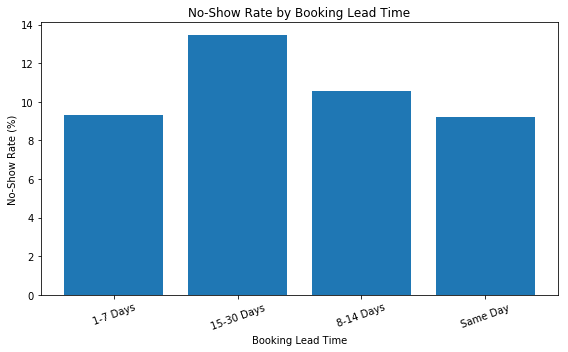

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    booking_lead_analysis["booking_lead_group"],
    booking_lead_analysis["no_show_rate"]
)

plt.title("No-Show Rate by Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("No-Show Rate (%)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [27]:
department_appointment_analysis = (
    appointments
    .groupby("department_id")
    .agg({
        "appointment_id": "count"
    })
    .reset_index()
)

department_appointment_analysis.columns = [
    "department_id",
    "total_appointments"
]

department_appointment_analysis = pd.merge(
    department_appointment_analysis,
    departments[
        [
            "department_id",
            "department_name",
            "location"
        ]
    ],
    on="department_id",
    how="left"
)

department_appointment_analysis["appointment_share"] = (
    department_appointment_analysis["total_appointments"]
    / len(appointments)
    * 100
).round(2)

department_appointment_analysis = (
    department_appointment_analysis
    .sort_values(
        "total_appointments",
        ascending=False
    )
    .reset_index(drop=True)
)

department_appointment_analysis

,department_id,total_appointments,department_name,location,appointment_share
0,D001,31724,Cardiology,Bengaluru,21.15
1,D004,24172,Pediatrics,Hyderabad,16.11
2,D006,17001,General Medicine,Pune,11.33
3,D010,16837,General Surgery,Bhubaneswar,11.22
4,D002,15063,Orthopedics,Mumbai,10.04
5,D008,13065,ENT,Ahmedabad,8.71
6,D003,9407,Dermatology,Delhi,6.27
7,D007,9345,Gynecology,Kolkata,6.23
8,D005,7684,Neurology,Chennai,5.12
9,D009,5702,Ophthalmology,Jaipur,3.80


In [28]:
department_status_analysis = (
    appointments
    .groupby(
        [
            "department_id",
            "appointment_status"
        ]
    )
    .size()
    .reset_index(
        name="appointment_count"
    )
)

department_status_analysis = pd.merge(
    department_status_analysis,
    departments[
        [
            "department_id",
            "department_name",
            "location"
        ]
    ],
    on="department_id",
    how="left"
)

department_status_analysis

,department_id,appointment_status,appointment_count,department_name,location
0,D001,Cancelled,1955,Cardiology,Bengaluru
1,D001,Completed,26847,Cardiology,Bengaluru
2,D001,No Show,2922,Cardiology,Bengaluru
3,D002,Cancelled,1045,Orthopedics,Mumbai
4,D002,Completed,12444,Orthopedics,Mumbai
5,D002,No Show,1574,Orthopedics,Mumbai
6,D003,Cancelled,689,Dermatology,Delhi
7,D003,Completed,7680,Dermatology,Delhi
8,D003,No Show,1038,Dermatology,Delhi
9,D004,Cancelled,1899,Pediatrics,Hyderabad


In [29]:
department_no_show = (
    appointments
    .groupby("department_id")
    .agg({
        "appointment_id": "count"
    })
    .reset_index()
)

department_no_show.columns = [
    "department_id",
    "total_appointments"
]

no_show_counts = (
    appointments[
        appointments["appointment_status"] == "No Show"
    ]
    .groupby("department_id")
    .size()
    .reset_index(
        name="no_show_count"
    )
)

department_no_show = pd.merge(
    department_no_show,
    no_show_counts,
    on="department_id",
    how="left"
)

department_no_show["no_show_count"] = (
    department_no_show["no_show_count"]
    .fillna(0)
)

department_no_show["no_show_rate"] = (
    department_no_show["no_show_count"]
    / department_no_show["total_appointments"]
    * 100
).round(2)

department_no_show = pd.merge(
    department_no_show,
    departments[
        [
            "department_id",
            "department_name",
            "location"
        ]
    ],
    on="department_id",
    how="left"
)

department_no_show = (
    department_no_show
    .sort_values(
        "no_show_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

department_no_show

,department_id,total_appointments,no_show_count,no_show_rate,department_name,location
0,D006,17001,2432,14.31,General Medicine,Pune
1,D010,16837,2257,13.41,General Surgery,Bhubaneswar
2,D004,24172,3064,12.68,Pediatrics,Hyderabad
3,D008,13065,1586,12.14,ENT,Ahmedabad
4,D005,7684,913,11.88,Neurology,Chennai
5,D003,9407,1038,11.03,Dermatology,Delhi
6,D007,9345,1023,10.95,Gynecology,Kolkata
7,D002,15063,1574,10.45,Orthopedics,Mumbai
8,D009,5702,590,10.35,Ophthalmology,Jaipur
9,D001,31724,2922,9.21,Cardiology,Bengaluru


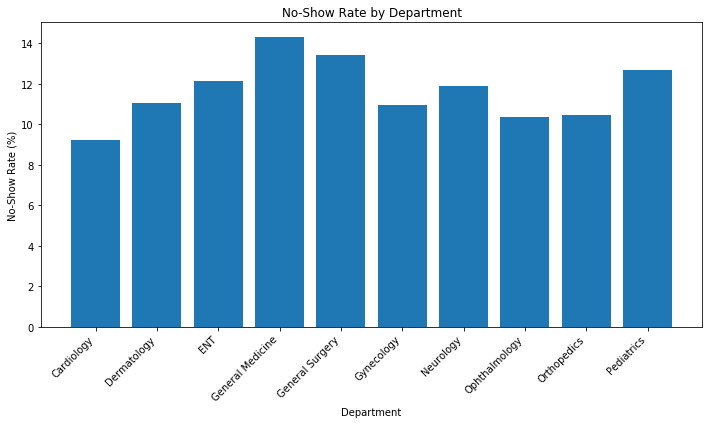

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(
    department_no_show["department_name"],
    department_no_show["no_show_rate"]
)

plt.title("No-Show Rate by Department")
plt.xlabel("Department")
plt.ylabel("No-Show Rate (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [31]:
def booking_group(days):
    if days == 0:
        return "Same Day"
    elif days <= 7:
        return "1-7 Days"
    elif days <= 14:
        return "8-14 Days"
    elif days <= 30:
        return "15-30 Days"
    else:
        return "31+ Days"


appointments["booking_lead_group"] = (
    appointments["scheduled_days_ahead"]
    .apply(booking_group)
)

booking_lead_analysis = (
    appointments
    .groupby("booking_lead_group")
    .agg({
        "appointment_id": "count"
    })
    .reset_index()
)

booking_lead_analysis.columns = [
    "booking_lead_group",
    "total_appointments"
]

booking_no_show = (
    appointments[
        appointments["appointment_status"] == "No Show"
    ]
    .groupby("booking_lead_group")
    .size()
    .reset_index(
        name="no_show_count"
    )
)

booking_lead_analysis = pd.merge(
    booking_lead_analysis,
    booking_no_show,
    on="booking_lead_group",
    how="left"
)

booking_lead_analysis["no_show_count"] = (
    booking_lead_analysis["no_show_count"]
    .fillna(0)
)

booking_lead_analysis["no_show_rate"] = (
    booking_lead_analysis["no_show_count"]
    / booking_lead_analysis["total_appointments"]
    * 100
).round(2)

booking_lead_analysis

,booking_lead_group,total_appointments,no_show_count,no_show_rate
0,1-7 Days,32287,3008,9.32
1,15-30 Days,73746,9908,13.44
2,8-14 Days,31983,3377,10.56
3,Same Day,11984,1106,9.23


In [32]:
appointments["appointment_month"] = (
    appointments["appointment_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_appointments = (
    appointments
    .groupby("appointment_month")
    .agg({
        "appointment_id": "count"
    })
    .reset_index()
)

monthly_appointments.columns = [
    "appointment_month",
    "total_appointments"
]

monthly_appointments

,appointment_month,total_appointments
0,2025-01,12673
1,2025-02,11516
2,2025-03,12495
3,2025-04,12207
4,2025-05,12735
5,2025-06,12497
6,2025-07,12625
7,2025-08,12978
8,2025-09,12530
9,2025-10,12845


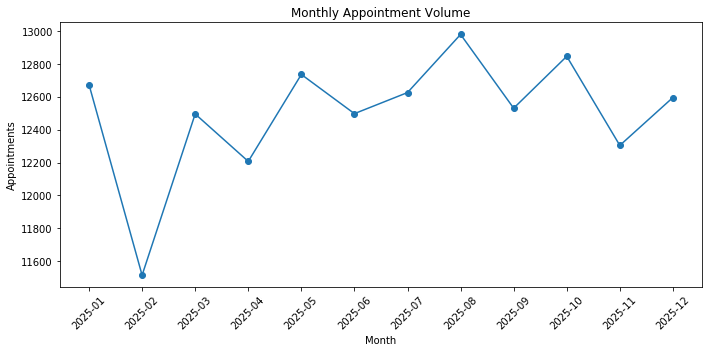

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_appointments["appointment_month"],
    monthly_appointments["total_appointments"],
    marker="o"
)

plt.title("Monthly Appointment Volume")
plt.xlabel("Month")
plt.ylabel("Appointments")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:
patient_age_analysis = (
    patients
    .groupby("age_group")
    .size()
    .reset_index(name="patient_count")
)

patient_age_analysis["percentage"] = (
    patient_age_analysis["patient_count"]
    / len(patients)
    * 100
).round(2)

patient_age_analysis

,age_group,patient_count,percentage
0,18-29,505,8.42
1,30-39,865,14.42
2,40-49,1210,20.17
3,50-59,1238,20.63
4,60-69,961,16.02
5,70+,1221,20.35


In [35]:
insurance_analysis = (
    patients
    .groupby("insurance_type")
    .size()
    .reset_index(name="patient_count")
)

insurance_analysis["percentage"] = (
    insurance_analysis["patient_count"]
    / len(patients)
    * 100
).round(2)

insurance_analysis = (
    insurance_analysis
    .sort_values(
        "patient_count",
        ascending=False
    )
    .reset_index(drop=True)
)

insurance_analysis

,insurance_type,patient_count,percentage
0,Private,2640,44.00
1,Government,1218,20.30
2,Corporate,1192,19.87
3,Self-Pay,950,15.83


In [36]:
billing_summary = pd.DataFrame({
    "metric": [
        "Total Bills",
        "Total Billing",
        "Average Bill",
        "Minimum Bill",
        "Maximum Bill"
    ],
    "value": [
        len(billing),
        billing["total_amount"].sum(),
        billing["total_amount"].mean(),
        billing["total_amount"].min(),
        billing["total_amount"].max()
    ]
})

billing_summary

,metric,value
0,Total Bills,1.219770e+05
1,Total Billing,2.484786e+08
2,Average Bill,2.037094e+03
3,Minimum Bill,3.975300e+02
4,Maximum Bill,1.306065e+04


In [37]:
billing_summary["value"] = (
    billing_summary["value"].round(2)
)

billing_summary

,metric,value
0,Total Bills,1.219770e+05
1,Total Billing,2.484786e+08
2,Average Bill,2.037090e+03
3,Minimum Bill,3.975300e+02
4,Maximum Bill,1.306065e+04


In [38]:
department_billing = (
    billing
    .groupby("department_id")
    .agg({
        "bill_id": "count",
        "total_amount": ["sum", "mean"]
    })
    .reset_index()
)

department_billing.columns = [
    "department_id",
    "bill_count",
    "total_billing",
    "average_bill_amount"
]

department_billing = pd.merge(
    department_billing,
    departments[
        [
            "department_id",
            "department_name",
            "location"
        ]
    ],
    on="department_id",
    how="left"
)

department_billing["total_billing"] = (
    department_billing["total_billing"].round(2)
)

department_billing["average_bill_amount"] = (
    department_billing["average_bill_amount"].round(2)
)

department_billing = (
    department_billing
    .sort_values(
        "total_billing",
        ascending=False
    )
    .reset_index(drop=True)
)

department_billing

,department_id,bill_count,total_billing,average_bill_amount,department_name,location
0,D001,26847,58932264.49,2195.12,Cardiology,Bengaluru
1,D004,19209,36003188.65,1874.29,Pediatrics,Hyderabad
2,D010,13310,30338824.71,2279.40,General Surgery,Bhubaneswar
3,D002,12444,25977046.64,2087.52,Orthopedics,Mumbai
4,D006,13248,23832376.32,1798.94,General Medicine,Pune
5,D008,10499,19239473.72,1832.51,ENT,Ahmedabad
6,D007,7743,15607031.59,2015.63,Gynecology,Kolkata
7,D003,7680,14884030.49,1938.02,Dermatology,Delhi
8,D005,6248,14687600.15,2350.77,Neurology,Chennai
9,D009,4749,8976801.50,1890.25,Ophthalmology,Jaipur


In [39]:
billing_insurance = pd.merge(
    billing,
    patients[
        [
            "patient_id",
            "insurance_type"
        ]
    ],
    on="patient_id",
    how="left"
)

insurance_billing = (
    billing_insurance
    .groupby("insurance_type")
    .agg({
        "bill_id": "count",
        "total_amount": ["sum", "mean"]
    })
    .reset_index()
)

insurance_billing.columns = [
    "insurance_type",
    "bill_count",
    "total_billing",
    "average_bill_amount"
]

insurance_billing["total_billing"] = (
    insurance_billing["total_billing"].round(2)
)

insurance_billing["average_bill_amount"] = (
    insurance_billing["average_bill_amount"].round(2)
)

insurance_billing = (
    insurance_billing
    .sort_values(
        "total_billing",
        ascending=False
    )
    .reset_index(drop=True)
)

insurance_billing

,insurance_type,bill_count,total_billing,average_bill_amount
0,Private,53887,1.097639e+08,2036.93
1,Government,24713,5.010175e+07,2027.34
2,Corporate,24195,4.951815e+07,2046.63
3,Self-Pay,19182,3.909479e+07,2038.10


In [40]:
provider_workload = (
    appointments
    .groupby("provider_id")
    .agg({
        "appointment_id": "count"
    })
    .reset_index()
)

provider_workload.columns = [
    "provider_id",
    "total_appointments"
]

completed_by_provider = (
    appointments[
        appointments["appointment_status"] == "Completed"
    ]
    .groupby("provider_id")
    .size()
    .reset_index(
        name="completed_appointments"
    )
)

no_show_by_provider = (
    appointments[
        appointments["appointment_status"] == "No Show"
    ]
    .groupby("provider_id")
    .size()
    .reset_index(
        name="no_show_count"
    )
)

provider_workload = pd.merge(
    provider_workload,
    completed_by_provider,
    on="provider_id",
    how="left"
)

provider_workload = pd.merge(
    provider_workload,
    no_show_by_provider,
    on="provider_id",
    how="left"
)

provider_workload[
    [
        "completed_appointments",
        "no_show_count"
    ]
] = provider_workload[
    [
        "completed_appointments",
        "no_show_count"
    ]
].fillna(0)

provider_workload["completion_rate"] = (
    provider_workload["completed_appointments"]
    / provider_workload["total_appointments"]
    * 100
).round(2)

provider_workload["no_show_rate"] = (
    provider_workload["no_show_count"]
    / provider_workload["total_appointments"]
    * 100
).round(2)

In [41]:
provider_workload = pd.merge(
    provider_workload,
    providers[
        [
            "provider_id",
            "provider_name",
            "department_id",
            "experience_years",
            "provider_type"
        ]
    ],
    on="provider_id",
    how="left"
)

provider_workload = pd.merge(
    provider_workload,
    departments[
        [
            "department_id",
            "department_name",
            "location"
        ]
    ],
    on="department_id",
    how="left"
)

provider_workload = (
    provider_workload
    .sort_values(
        "total_appointments",
        ascending=False
    )
    .reset_index(drop=True)
)

provider_workload.head(10)

,provider_id,total_appointments,completed_appointments,no_show_count,completion_rate,no_show_rate,provider_name,department_id,experience_years,provider_type,department_name,location
0,PR056,1985,1575,255,79.35,12.85,Dr. Nisha Kulkarni,D010,14,Consultant,General Surgery,Bhubaneswar
1,PR022,1967,1582,250,80.43,12.71,Dr. Aditi Nair,D005,15,Specialist,Neurology,Chennai
2,PR050,1966,1495,310,76.04,15.77,Dr. Priya Iyer,D006,22,Consultant,General Medicine,Pune
3,PR016,1965,1670,163,84.99,8.30,Dr. Nisha Das,D001,13,Consultant,Cardiology,Bengaluru
4,PR037,1948,1605,204,82.39,10.47,Dr. Kavya Rao,D003,15,Consultant,Dermatology,Delhi
5,PR019,1939,1538,253,79.32,13.05,Dr. Diya Patel,D004,3,Specialist,Pediatrics,Hyderabad
6,PR049,1938,1624,194,83.80,10.01,Dr. Pooja Rao,D002,5,Consultant,Orthopedics,Mumbai
7,PR015,1935,1583,221,81.81,11.42,Dr. Aarav Reddy,D005,5,Consultant,Neurology,Chennai
8,PR025,1930,1621,200,83.99,10.36,Dr. Diya Mehta,D009,18,Consultant,Ophthalmology,Jaipur
9,PR034,1926,1631,182,84.68,9.45,Dr. Rahul Gupta,D001,22,Specialist,Cardiology,Bengaluru


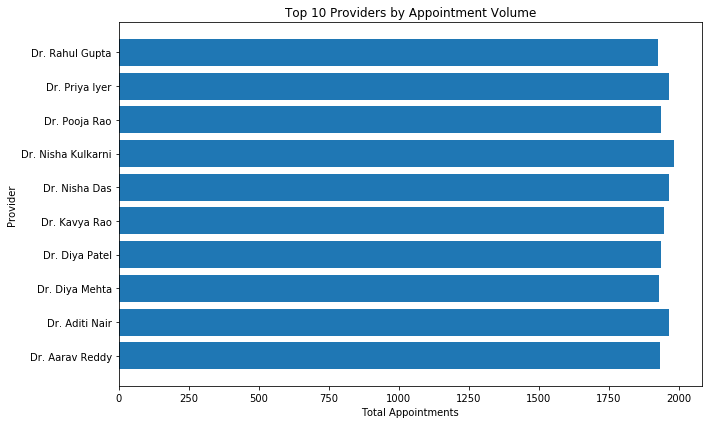

In [42]:
top_providers = (
    provider_workload
    .head(10)
    .sort_values(
        "total_appointments",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_providers["provider_name"],
    top_providers["total_appointments"]
)

plt.title("Top 10 Providers by Appointment Volume")
plt.xlabel("Total Appointments")
plt.ylabel("Provider")

plt.tight_layout()
plt.show()

In [43]:
billing_components = pd.DataFrame({
    "component": [
        "Consultation Fee",
        "Procedure Amount",
        "Medication Amount"
    ],
    "total_amount": [
        billing["consultation_fee"].sum(),
        billing["procedure_amount"].sum(),
        billing["medication_amount"].sum()
    ]
})

billing_components["total_amount"] = (
    billing_components["total_amount"].round(2)
)

billing_components["percentage"] = (
    billing_components["total_amount"]
    / billing_components["total_amount"].sum()
    * 100
).round(2)

billing_components

,component,total_amount,percentage
0,Consultation Fee,91503981.51,36.83
1,Procedure Amount,82944500.00,33.38
2,Medication Amount,74030156.75,29.79


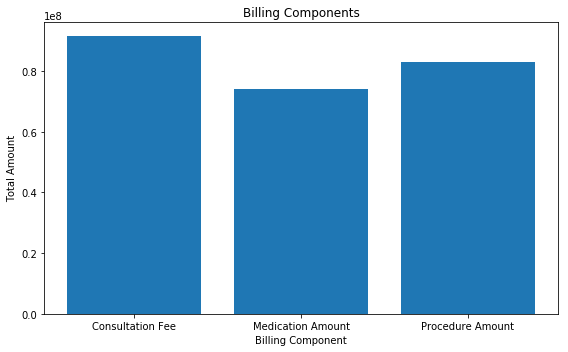

In [44]:
plt.figure(figsize=(8, 5))

plt.bar(
    billing_components["component"],
    billing_components["total_amount"]
)

plt.title("Billing Components")
plt.xlabel("Billing Component")
plt.ylabel("Total Amount")

plt.tight_layout()
plt.show()

In [45]:
department_wait_time
department_consultation_time
department_operational_analysis

,department_id,department_name,location,completed_visits,average_wait_minutes,average_consultation_minutes
0,D010,General Surgery,Bhubaneswar,13310,44.38,39.53
1,D005,Neurology,Chennai,6248,41.46,31.57
2,D004,Pediatrics,Hyderabad,19209,38.53,21.68
3,D007,Gynecology,Kolkata,7743,35.61,24.62
4,D002,Orthopedics,Mumbai,12444,33.43,27.61
5,D006,General Medicine,Pune,13248,30.42,17.91
6,D001,Cardiology,Bengaluru,26847,27.59,23.58
7,D008,ENT,Ahmedabad,10499,26.85,18.92
8,D003,Dermatology,Delhi,7680,23.86,19.86
9,D009,Ophthalmology,Jaipur,4749,22.12,20.65


In [46]:
department_operational_final = pd.merge(
    department_operational_analysis,
    department_billing[
        [
            "department_id",
            "bill_count",
            "total_billing",
            "average_bill_amount"
        ]
    ],
    on="department_id",
    how="left"
)

department_operational_final = pd.merge(
    department_operational_final,
    department_no_show[
        [
            "department_id",
            "total_appointments",
            "no_show_count",
            "no_show_rate"
        ]
    ],
    on="department_id",
    how="left"
)

In [47]:
department_operational_final = (
    department_operational_final
    .drop(
        columns=["total_appointments_y"],
        errors="ignore"
    )
)

In [48]:
department_operational_final = (
    department_operational_final
    .sort_values(
        "average_wait_minutes",
        ascending=False
    )
    .reset_index(drop=True)
)

department_operational_final

,department_id,department_name,location,completed_visits,average_wait_minutes,average_consultation_minutes,bill_count,total_billing,average_bill_amount,total_appointments,no_show_count,no_show_rate
0,D010,General Surgery,Bhubaneswar,13310,44.38,39.53,13310,30338824.71,2279.40,16837,2257,13.41
1,D005,Neurology,Chennai,6248,41.46,31.57,6248,14687600.15,2350.77,7684,913,11.88
2,D004,Pediatrics,Hyderabad,19209,38.53,21.68,19209,36003188.65,1874.29,24172,3064,12.68
3,D007,Gynecology,Kolkata,7743,35.61,24.62,7743,15607031.59,2015.63,9345,1023,10.95
4,D002,Orthopedics,Mumbai,12444,33.43,27.61,12444,25977046.64,2087.52,15063,1574,10.45
5,D006,General Medicine,Pune,13248,30.42,17.91,13248,23832376.32,1798.94,17001,2432,14.31
6,D001,Cardiology,Bengaluru,26847,27.59,23.58,26847,58932264.49,2195.12,31724,2922,9.21
7,D008,ENT,Ahmedabad,10499,26.85,18.92,10499,19239473.72,1832.51,13065,1586,12.14
8,D003,Dermatology,Delhi,7680,23.86,19.86,7680,14884030.49,1938.02,9407,1038,11.03
9,D009,Ophthalmology,Jaipur,4749,22.12,20.65,4749,8976801.50,1890.25,5702,590,10.35


In [49]:
appointment_status_summary
department_appointment_analysis
department_status_analysis
department_no_show
booking_lead_analysis
monthly_appointments
patient_age_analysis
insurance_analysis
billing_summary
department_billing
insurance_billing
provider_workload
billing_components
department_operational_analysis
department_operational_final

,department_id,department_name,location,completed_visits,average_wait_minutes,average_consultation_minutes,bill_count,total_billing,average_bill_amount,total_appointments,no_show_count,no_show_rate
0,D010,General Surgery,Bhubaneswar,13310,44.38,39.53,13310,30338824.71,2279.40,16837,2257,13.41
1,D005,Neurology,Chennai,6248,41.46,31.57,6248,14687600.15,2350.77,7684,913,11.88
2,D004,Pediatrics,Hyderabad,19209,38.53,21.68,19209,36003188.65,1874.29,24172,3064,12.68
3,D007,Gynecology,Kolkata,7743,35.61,24.62,7743,15607031.59,2015.63,9345,1023,10.95
4,D002,Orthopedics,Mumbai,12444,33.43,27.61,12444,25977046.64,2087.52,15063,1574,10.45
5,D006,General Medicine,Pune,13248,30.42,17.91,13248,23832376.32,1798.94,17001,2432,14.31
6,D001,Cardiology,Bengaluru,26847,27.59,23.58,26847,58932264.49,2195.12,31724,2922,9.21
7,D008,ENT,Ahmedabad,10499,26.85,18.92,10499,19239473.72,1832.51,13065,1586,12.14
8,D003,Dermatology,Delhi,7680,23.86,19.86,7680,14884030.49,1938.02,9407,1038,11.03
9,D009,Ophthalmology,Jaipur,4749,22.12,20.65,4749,8976801.50,1890.25,5702,590,10.35


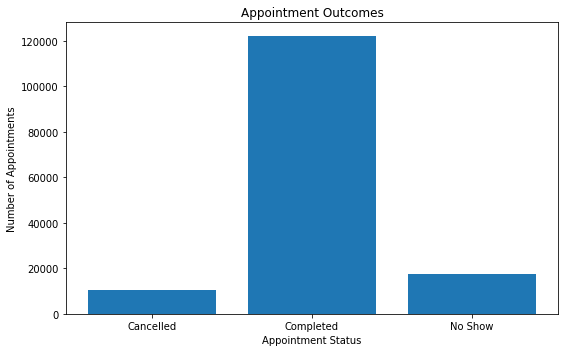

In [50]:
plt.figure(figsize=(8, 5))

plt.bar(
    appointment_status_summary["appointment_status"],
    appointment_status_summary["appointment_count"]
)

plt.title("Appointment Outcomes")
plt.xlabel("Appointment Status")
plt.ylabel("Number of Appointments")

plt.tight_layout()
plt.show()

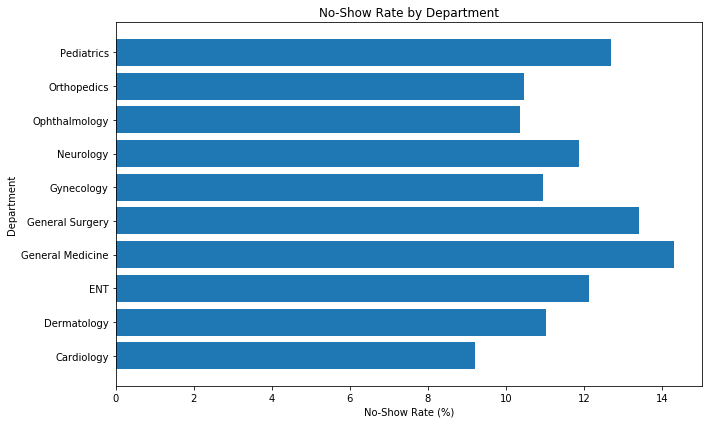

In [51]:
no_show_chart = (
    department_no_show
    .sort_values(
        "no_show_rate",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    no_show_chart["department_name"],
    no_show_chart["no_show_rate"]
)

plt.title("No-Show Rate by Department")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

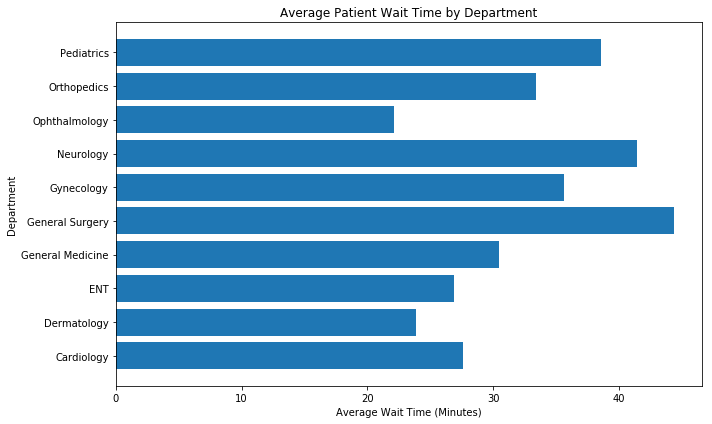

In [52]:
wait_chart = (
    department_wait_time
    .sort_values(
        "average_wait_minutes",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    wait_chart["department_name"],
    wait_chart["average_wait_minutes"]
)

plt.title("Average Patient Wait Time by Department")
plt.xlabel("Average Wait Time (Minutes)")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

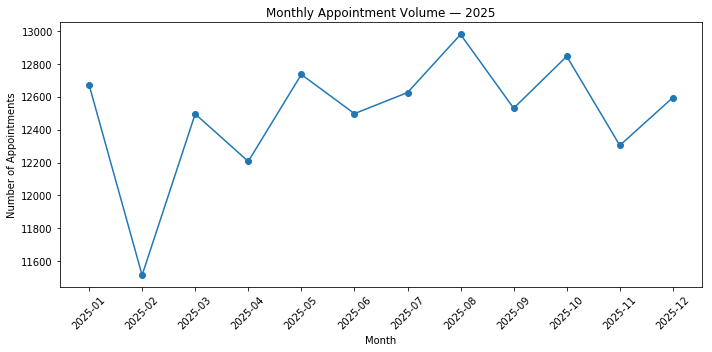

In [53]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_appointments["appointment_month"],
    monthly_appointments["total_appointments"],
    marker="o"
)

plt.title("Monthly Appointment Volume — 2025")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

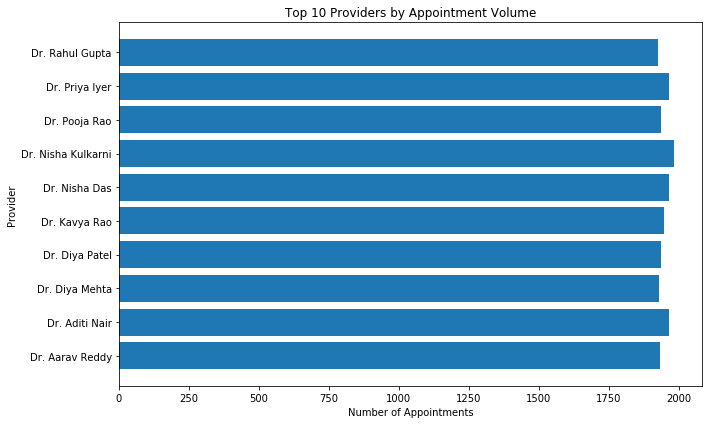

In [54]:
top_providers = (
    provider_workload
    .head(10)
    .sort_values(
        "total_appointments",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_providers["provider_name"],
    top_providers["total_appointments"]
)

plt.title("Top 10 Providers by Appointment Volume")
plt.xlabel("Number of Appointments")
plt.ylabel("Provider")

plt.tight_layout()
plt.show()

In [55]:
total_appointments = len(appointments)

completed_appointments = (
    (appointments["appointment_status"] == "Completed")
    .sum()
)

no_show_appointments = (
    (appointments["appointment_status"] == "No Show")
    .sum()
)

cancelled_appointments = (
    (appointments["appointment_status"] == "Cancelled")
    .sum()
)

overall_no_show_rate = (
    no_show_appointments
    / total_appointments
    * 100
)

average_wait_time = (
    visits["wait_time_minutes"]
    .mean()
)

average_consultation_time = (
    visits["consultation_duration_minutes"]
    .mean()
)

total_billing = billing["total_amount"].sum()

average_bill = billing["total_amount"].mean()

healthcare_kpis = pd.DataFrame({
    "KPI": [
        "Total Patients",
        "Total Appointments",
        "Completed Appointments",
        "No-Show Rate",
        "Cancelled Appointments",
        "Average Wait Time",
        "Average Consultation Time",
        "Total Billing",
        "Average Bill"
    ],
    "Value": [
        len(patients),
        total_appointments,
        completed_appointments,
        round(overall_no_show_rate, 2),
        cancelled_appointments,
        round(average_wait_time, 2),
        round(average_consultation_time, 2),
        round(total_billing, 2),
        round(average_bill, 2)
    ]
})

healthcare_kpis

,KPI,Value
0,Total Patients,6.000000e+03
1,Total Appointments,1.500000e+05
2,Completed Appointments,1.219770e+05
3,No-Show Rate,1.160000e+01
4,Cancelled Appointments,1.062400e+04
5,Average Wait Time,3.275000e+01
6,Average Consultation Time,2.454000e+01
7,Total Billing,2.484786e+08
8,Average Bill,2.037090e+03


In [56]:
department_operational_final

,department_id,department_name,location,completed_visits,average_wait_minutes,average_consultation_minutes,bill_count,total_billing,average_bill_amount,total_appointments,no_show_count,no_show_rate
0,D010,General Surgery,Bhubaneswar,13310,44.38,39.53,13310,30338824.71,2279.40,16837,2257,13.41
1,D005,Neurology,Chennai,6248,41.46,31.57,6248,14687600.15,2350.77,7684,913,11.88
2,D004,Pediatrics,Hyderabad,19209,38.53,21.68,19209,36003188.65,1874.29,24172,3064,12.68
3,D007,Gynecology,Kolkata,7743,35.61,24.62,7743,15607031.59,2015.63,9345,1023,10.95
4,D002,Orthopedics,Mumbai,12444,33.43,27.61,12444,25977046.64,2087.52,15063,1574,10.45
5,D006,General Medicine,Pune,13248,30.42,17.91,13248,23832376.32,1798.94,17001,2432,14.31
6,D001,Cardiology,Bengaluru,26847,27.59,23.58,26847,58932264.49,2195.12,31724,2922,9.21
7,D008,ENT,Ahmedabad,10499,26.85,18.92,10499,19239473.72,1832.51,13065,1586,12.14
8,D003,Dermatology,Delhi,7680,23.86,19.86,7680,14884030.49,1938.02,9407,1038,11.03
9,D009,Ophthalmology,Jaipur,4749,22.12,20.65,4749,8976801.50,1890.25,5702,590,10.35


In [57]:
department_operational_final

,department_id,department_name,location,completed_visits,average_wait_minutes,average_consultation_minutes,bill_count,total_billing,average_bill_amount,total_appointments,no_show_count,no_show_rate
0,D010,General Surgery,Bhubaneswar,13310,44.38,39.53,13310,30338824.71,2279.40,16837,2257,13.41
1,D005,Neurology,Chennai,6248,41.46,31.57,6248,14687600.15,2350.77,7684,913,11.88
2,D004,Pediatrics,Hyderabad,19209,38.53,21.68,19209,36003188.65,1874.29,24172,3064,12.68
3,D007,Gynecology,Kolkata,7743,35.61,24.62,7743,15607031.59,2015.63,9345,1023,10.95
4,D002,Orthopedics,Mumbai,12444,33.43,27.61,12444,25977046.64,2087.52,15063,1574,10.45
5,D006,General Medicine,Pune,13248,30.42,17.91,13248,23832376.32,1798.94,17001,2432,14.31
6,D001,Cardiology,Bengaluru,26847,27.59,23.58,26847,58932264.49,2195.12,31724,2922,9.21
7,D008,ENT,Ahmedabad,10499,26.85,18.92,10499,19239473.72,1832.51,13065,1586,12.14
8,D003,Dermatology,Delhi,7680,23.86,19.86,7680,14884030.49,1938.02,9407,1038,11.03
9,D009,Ophthalmology,Jaipur,4749,22.12,20.65,4749,8976801.50,1890.25,5702,590,10.35
